###

In [7]:
import pandas as pd
import matplotlib as plt
import seaborn as sns


In [3]:
df=pd.read_csv('weight-height.csv')

In [4]:
df.head(5)

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  object 
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), object(1)
memory usage: 234.5+ KB


### Detect and Remove Outliers

In [6]:
df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


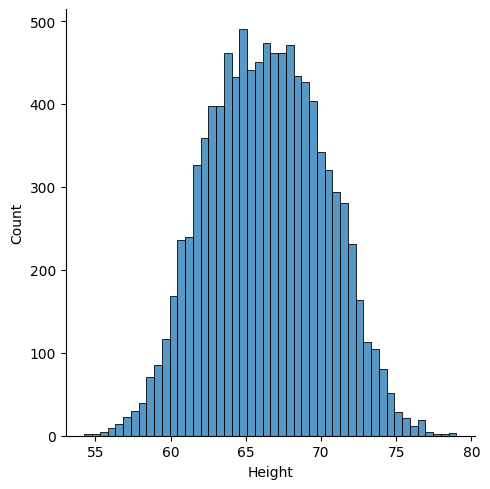

In [8]:
sns.displot(df['Height'])

<Axes: ylabel='Height'>

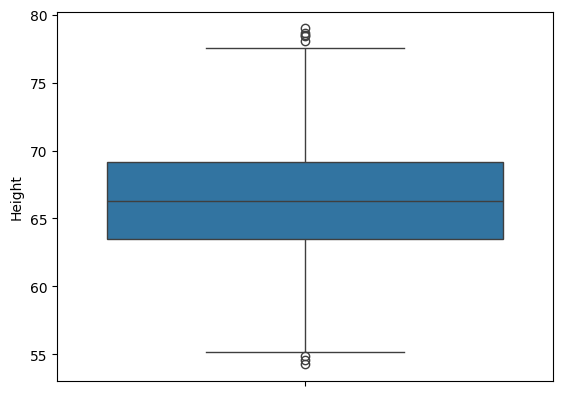

In [9]:
sns.boxplot(df['Height'])

### Methods of handling outliers

##### Z-score method

In [ ]:
# find the limits

upper_limit =df['Height'].mean()+1.5*df['Height'].std()
lower_limit =df['Height'].mean()-1.5*df['Height'].std()

upper_limit , lower_limit

(np.float64(72.13885193598108), np.float64(60.5962675736614))

In [17]:
#find the outliers

df.loc[(df['Height']>upper_limit) | (df['Height']<lower_limit )]

,Gender,Height,Weight
0,Male,73.847017,241.893563
2,Male,74.110105,212.740856
16,Male,72.418317,196.028506
23,Male,75.205974,228.761781
27,Male,72.800844,206.828189
...,...,...,...
9981,Female,60.443264,135.559390
9984,Female,59.047029,111.707369
9988,Female,59.538729,121.244876
9993,Female,60.030434,97.687432


In [22]:
# triming - deleting the outlier data

new_df =  df.loc[(df['Height']<upper_limit) & (df['Height']>lower_limit )]
print(len(new_df))

8707


<Axes: ylabel='Height'>

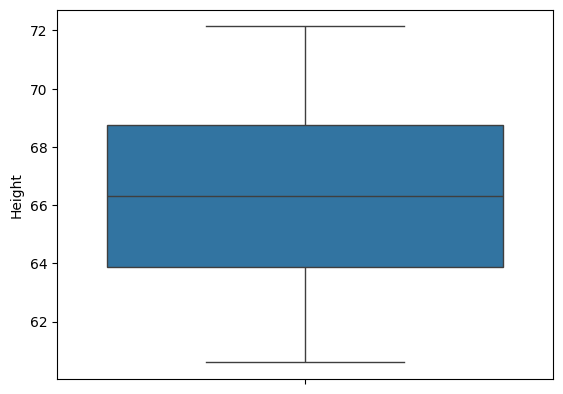

In [23]:
sns.boxplot(new_df['Height'])

In [27]:
#capping - chanding the outlier values into upper and lower values
# used instead of dropping the whole row
# filtering out the data that is upper limit value and replacing them into upper limit value
# we do the same for lower limit

new_df2 = df.copy()

new_df2.loc[new_df2['Height']>upper_limit , 'Height' ]= upper_limit
new_df2.loc[new_df2['Height']<lower_limit , 'Height' ]= lower_limit
print(len(new_df2))

10000


<Axes: ylabel='Height'>

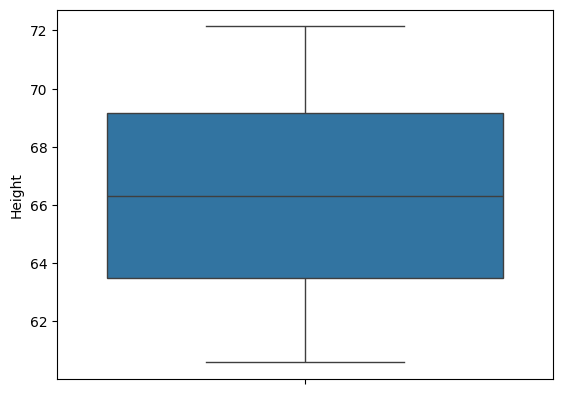

In [26]:
sns.boxplot(new_df2['Height'])

### IQR Method

In [30]:
q1  = df['Height'].quantile(0.25)
q3  = df['Height'].quantile(0.75)
iqr = q3 - q1
print(q1 ,q3 , iqr)

63.505620481218955 69.1742617268347 5.668641245615746


In [32]:
upper=  q3+(1.5*iqr)
lower= q1-(1.5*iqr)
print(upper,lower)

77.67722359525831 55.00265861279534


<Axes: ylabel='Height'>

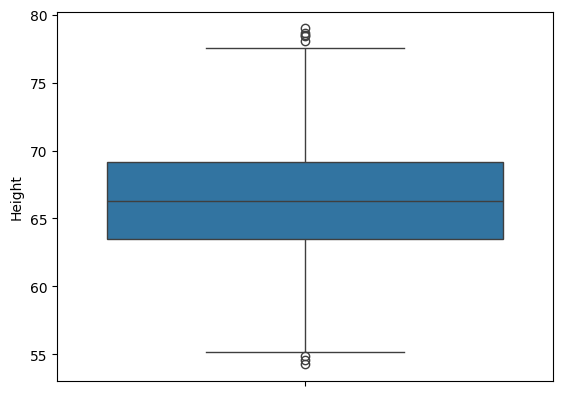

In [33]:
sns.boxplot(df['Height'])

In [35]:
#find the outliers

df.loc[(df['Height']>upper) | (df['Height']<lower )]

,Gender,Height,Weight
994,Male,78.095867,255.690835
1317,Male,78.462053,227.342565
2014,Male,78.998742,269.989699
3285,Male,78.528210,253.889004
3757,Male,78.621374,245.733783
6624,Female,54.616858,71.393749
7294,Female,54.873728,78.606670
9285,Female,54.263133,64.700127


In [36]:
# triming - deleting the outlier data

new_df =  df.loc[(df['Height']<upper_limit) & (df['Height']>lower_limit )]
print(len(new_df))

8707
